<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/PostPKAC_Servival_analysis26_june26_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
sheets = pd.ExcelFile('/content/drive/MyDrive/karthik_vr_thesis_with_survival_variables.xlsx')
sheets.sheet_names


['raw data',
 'Preop data',
 'Sheet1',
 'Post OP 1wk data',
 'Post OP 1mth data',
 'Post OP 3mth data',
 'reformation time',
 'Age']

In [ ]:
sheet1 = sheets.parse('Sheet1')
sheet1.head()

,Name of recepient,Age,Sex,Operating eye,Preop ACD,Preop ACA,Preop LV,Preop CCT,ACD 1 wk,ACA 1 wk,...,ACA 3 mth,LV 3 mth,CCT 3 mth,Mean Preop SSA,Mean 1wk SSA,Mean 1mth SSA,Mean 3mth SSA,ACD_90pct_Threshold,AC_reformation_time,AC_reformation_event
0,Rajappa,60,M,LE,1.20,12.50,500,650,NaN,NaN,...,NaN,NaN,NaN,13.5,NaN,NaN,NaN,1.080,90,0
1,Channegowda,72,M,RE,1.88,11.93,213,904,1.76,14.20,...,NaN,NaN,NaN,41.0,47.5,40.0,NaN,1.692,7,1
2,Janakkamma,78,F,LE,1.86,11.30,1134,622,1.40,10.00,...,NaN,NaN,NaN,38.5,42.0,31.5,NaN,1.674,90,0
3,Shankara B,59,M,RE,1.40,13.20,300,460,2.91,6.47,...,8.43,-300.0,620.0,49.5,61.0,54.0,NaN,1.260,7,1
4,Nanjappa,80,M,RE,1.24,9.00,200,543,2.46,18.40,...,18.40,-346.0,503.0,38.0,36.0,NaN,36.0,1.116,7,1


In [ ]:
sheet1.columns

Index(['Name of recepient', 'Age', 'Sex', 'Operating eye', 'Preop ACD',
       'Preop ACA', 'Preop LV', 'Preop CCT', 'ACD 1 wk', 'ACA 1 wk', 'LV 1 wk',
       'CCT 1 wk', 'ACD 1 mth', 'ACA 1 mth', 'LV 1 mth', 'CCT 1 mth',
       'ACD 3 mth', 'ACA 3 mth', 'LV 3 mth', 'CCT 3 mth', 'Mean Preop SSA',
       'Mean 1wk SSA', 'Mean 1mth SSA', 'Mean 3mth SSA', 'ACD_90pct_Threshold',
       'AC_reformation_time', 'AC_reformation_event'],
      dtype='object')

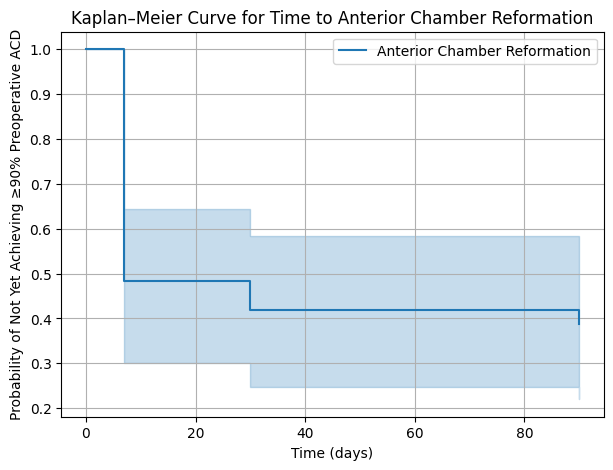

          Anterior Chamber Reformation
timeline                              
0.0                           1.000000
7.0                           0.483871
30.0                          0.419355
90.0                          0.387097
Median time to AC reformation: 7.0


In [ ]:
# Install lifelines (only once)
!pip install lifelines

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# sheet1 is already your DataFrame

# Initialize Kaplan-Meier estimator
kmf = KaplanMeierFitter()

# Fit the model
kmf.fit(
    durations=sheet1["AC_reformation_time"],
    event_observed=sheet1["AC_reformation_event"],
    label="Anterior Chamber Reformation"
)

# Plot
plt.figure(figsize=(7,5))
kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Curve for Time to Anterior Chamber Reformation")
plt.xlabel("Time (days)")
plt.ylabel("Probability of Not Yet Achieving ≥90% Preoperative ACD")
plt.grid(True)

plt.show()

# Survival probabilities
print(kmf.survival_function_)

# Median survival time
print("Median time to AC reformation:", kmf.median_survival_time_)

In [17]:
# Install lifelines (only once)
!pip install lifelines

import pandas as pd
from lifelines import CoxPHFitter

# Select variables for the Cox model
cox_data = sheet1[[
    "AC_reformation_time",
    "AC_reformation_event",
    "Preop CCT",
    "Preop ACD",
    "Preop ACA",
    "Mean Preop SSA"

]].copy()

# Remove rows with missing values
cox_data = cox_data.dropna()

# Fit Cox model
cph = CoxPHFitter()

cph.fit(
    cox_data,
    duration_col="AC_reformation_time",
    event_col="AC_reformation_event"
)

# Results
cph.print_summary()

# Hazard ratios with 95% CI
print(cph.summary[[
    "coef",
    "exp(coef)",
    "exp(coef) lower 95%",
    "exp(coef) upper 95%",
    "p"
]])

<lifelines.CoxPHFitter: fitted with 31 total observations, 12 right-censored observations>
             duration col = 'AC_reformation_time'
                event col = 'AC_reformation_event'
      baseline estimation = breslow
   number of observations = 31
number of events observed = 19
   partial log-likelihood = -52.52
         time fit was run = 2026-06-26 03:38:14 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Preop CCT       0.00      1.00      0.00            0.00            0.01                1.00                1.01
Preop ACD      -0.40      0.67      0.35           -1.07            0.28                0.34                1.33
Preop ACA       0.00      1.00      0.05           -0.10            0.10                0.90                1.11
Mean Preop SSA  0.01      1.01      0.02           -0.03            0.04                0.97                1.04

                cmp to     z    p  -log2(p)
covariate                                  
Preop CCT         0.00  2.55 0.01      6.53
Preop ACD         0.00 -1.14 0.25      1.99
Preop ACA         0.00  0.01 0.99      0.01
Mean Preop SSA    0.00  0.28 0.78      0.36
---
Concordance = 0.79
Partial AIC = 113.03
log-likelihood ratio test = 11.18 on 4 df
-log2(p) of ll-ratio test = 5.34

                    coef  exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                       
Preop CCT       0.003195   1.003200             1.000738             1.005668   
Preop ACD      -0.395767   0.673163             0.341750             1.325966   
Preop ACA       0.000410   1.000410             0.903187             1.108098   
Mean Preop SSA  0.005305   1.005319             0.968627             1.043401   

                       p  
covariate                 
Preop CCT       0.010809  
Preop ACD       0.252524  
Preop ACA       0.993729  
Mean Preop SSA  0.779743  


In [18]:
cph.check_assumptions(cox_data, p_value_threshold=0.05)

Proportional hazard assumption looks okay.


[]

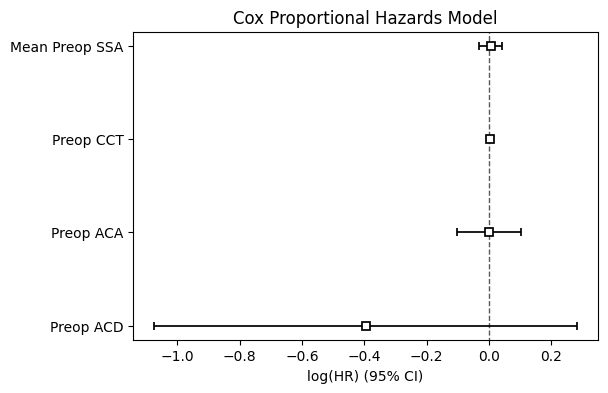

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
cph.plot()
plt.title("Cox Proportional Hazards Model")
plt.show()

In [20]:
variables = ["Preop CCT", "Preop ACD", "Preop ACA", "Mean Preop SSA"]

for var in variables:
    print("\n", "="*50)
    print("Variable:", var)

    df = sheet1[[
        "AC_reformation_time",
        "AC_reformation_event",
        var
    ]].dropna()

    cph = CoxPHFitter()
    cph.fit(df,
            duration_col="AC_reformation_time",
            event_col="AC_reformation_event")

    cph.print_summary()


Variable: Preop CCT


<lifelines.CoxPHFitter: fitted with 31 total observations, 12 right-censored observations>
             duration col = 'AC_reformation_time'
                event col = 'AC_reformation_event'
      baseline estimation = breslow
   number of observations = 31
number of events observed = 19
   partial log-likelihood = -54.04
         time fit was run = 2026-06-26 03:42:33 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Preop CCT  0.00      1.00      0.00            0.00            0.01                1.00                1.01

           cmp to    z      p  -log2(p)
covariate                              
Preop CCT    0.00 2.91 <0.005      8.12
---
Concordance = 0.76
Partial AIC = 110.08
log-likelihood ratio test = 8.13 on 1 df
-log2(p) of ll-ratio test = 7.84


Variable: Preop ACD


<lifelines.CoxPHFitter: fitted with 31 total observations, 12 right-censored observations>
             duration col = 'AC_reformation_time'
                event col = 'AC_reformation_event'
      baseline estimation = breslow
   number of observations = 31
number of events observed = 19
   partial log-likelihood = -55.50
         time fit was run = 2026-06-26 03:42:33 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Preop ACD -0.45      0.64      0.20           -0.85           -0.06                0.43                0.94

           cmp to     z    p  -log2(p)
covariate                             
Preop ACD    0.00 -2.27 0.02      5.44
---
Concordance = 0.69
Partial AIC = 113.00
log-likelihood ratio test = 5.21 on 1 df
-log2(p) of ll-ratio test = 5.48


Variable: Preop ACA


<lifelines.CoxPHFitter: fitted with 31 total observations, 12 right-censored observations>
             duration col = 'AC_reformation_time'
                event col = 'AC_reformation_event'
      baseline estimation = breslow
   number of observations = 31
number of events observed = 19
   partial log-likelihood = -56.70
         time fit was run = 2026-06-26 03:42:33 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Preop ACA -0.05      0.95      0.03           -0.10            0.01                0.90                1.01

           cmp to     z    p  -log2(p)
covariate                             
Preop ACA    0.00 -1.61 0.11      3.23
---
Concordance = 0.65
Partial AIC = 115.41
log-likelihood ratio test = 2.80 on 1 df
-log2(p) of ll-ratio test = 3.41


Variable: Mean Preop SSA


<lifelines.CoxPHFitter: fitted with 31 total observations, 12 right-censored observations>
             duration col = 'AC_reformation_time'
                event col = 'AC_reformation_event'
      baseline estimation = breslow
   number of observations = 31
number of events observed = 19
   partial log-likelihood = -57.79
         time fit was run = 2026-06-26 03:42:33 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
Mean Preop SSA -0.01      0.99      0.02           -0.05            0.02                0.95                1.02

                cmp to     z    p  -log2(p)
covariate                                  
Mean Preop SSA    0.00 -0.80 0.43      1.23
---
Concordance = 0.57
Partial AIC = 117.59
log-likelihood ratio test = 0.62 on 1 df
-log2(p) of ll-ratio test = 1.22